# Notebook 11b — Índices ENSO (ONI y SOI) de NOAA en R (tidyverse + ggplot2)

Replica en R, mediante el ecosistema `tidyverse`, la descarga y análisis de los índices ENSO globales del Climate Prediction Center de la NOAA ---ONI y SOI--- y su cruce con las anomalías NDVI del manglar de la CGSM, ya desarrollado en Python en el notebook `11_indices_enso_noaa.ipynb`. La elección de R para este análisis específico obedece a que las series climatológicas y de teleconexiones se trabajan tradicionalmente en R en la literatura del clima, en este sentido `dplyr` + `lubridate` + `ggplot2` ofrecen una sintaxis más concisa para el manejo de series mensuales y `purrr::map_dfr` permite iterar sobre rezagos temporales sin bucles explícitos. La convergencia numérica entre los dos notebooks ---Python y R--- constituye una validación adicional del análisis ENSO.

**Insumos:**
- NOAA CPC: ONI (https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt) y SOI (https://www.cpc.ncep.noaa.gov/data/indices/soi)
- `outputs/tables/serie_temporal_ndvi_definitiva.csv`

**Productos:**
- `outputs/tables/indices_enso_mensual_R.csv` (debe coincidir con `indices_enso_mensual.csv` del notebook 11)
- `outputs/tables/correlacion_enso_ndvi_R.csv`
- `outputs/figures/enso_serie_2013_2025_R.png`
- `outputs/figures/enso_vs_ndvi_correlacion_R.png`

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(readr)
  library(lubridate)
  library(ggplot2)
  library(purrr)
})

setwd('/home/rstudio/work/proyecto-cgsm')
URL_ONI  <- 'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt'
URL_SOI  <- 'https://www.cpc.ncep.noaa.gov/data/indices/soi'
NDVI_CSV <- 'outputs/tables/serie_temporal_ndvi_definitiva.csv'
OUT_TAB  <- 'outputs/tables'
OUT_FIG  <- 'outputs/figures'
dir.create(OUT_TAB, showWarnings = FALSE, recursive = TRUE)
dir.create(OUT_FIG, showWarnings = FALSE, recursive = TRUE)
cat('Setup R OK\n')

Setup R OK


## 1. Descarga y parseo del ONI

El ONI viene como tabla `SEAS YR TOTAL ANOM` donde `SEAS` es un trimestre móvil (DJF, JFM, etc.). Se asocia el valor de cada trimestre a su mes central, en este sentido la serie mensual resulta directamente comparable con las anomalías NDVI mensuales del proyecto.

In [2]:
oni_local <- file.path(OUT_TAB, 'oni_raw_R.txt')
download.file(URL_ONI, oni_local, quiet = TRUE, method = 'libcurl')
oni_raw <- read_table(oni_local, show_col_types = FALSE)

seas_map <- c('DJF'=1,'JFM'=2,'FMA'=3,'MAM'=4,'AMJ'=5,'MJJ'=6,
              'JJA'=7,'JAS'=8,'ASO'=9,'SON'=10,'OND'=11,'NDJ'=12)

oni <- oni_raw %>%
  mutate(month = seas_map[SEAS],
         date  = make_date(YR, month, 15),
         oni   = ANOM) %>%
  filter(date >= as.Date('2013-01-01'),
         date <= as.Date('2025-12-31')) %>%
  select(date, oni) %>%
  arrange(date)

cat(sprintf('ONI: %d registros, rango %.2f a %.2f\n',
            nrow(oni), min(oni$oni, na.rm=TRUE), max(oni$oni, na.rm=TRUE)))
print(tail(oni, 5))

ONI: 156 registros, rango -1.20 a 2.75
# A tibble: 5 × 2
  date         oni
  <date>     <dbl>
1 2025-08-15 -0.28
2 2025-09-15 -0.4 
3 2025-10-15 -0.51
4 2025-11-15 -0.55
5 2025-12-15 -0.54


## 2. Descarga y parseo del SOI

El SOI viene como matriz `YEAR JAN FEB ... DEC` con dos bloques (anomalía estandarizada arriba, anomalía cruda abajo). Se usa la versión estandarizada del bloque superior y se filtran los valores `-999.9` que la NOAA usa como `NoData`.

In [3]:
soi_local <- file.path(OUT_TAB, 'soi_raw_R.txt')
download.file(URL_SOI, soi_local, quiet = TRUE, method = 'libcurl')
lineas <- readLines(soi_local)

header_idx <- which(grepl('^\\s*YEAR.*JAN.*DEC', lineas))[1]
if (is.na(header_idx)) stop('No se encontró encabezado YEAR ... DEC en el SOI')

data_lines <- character()
for (i in (header_idx + 1):length(lineas)) {
  s <- trimws(lineas[i])
  if (nchar(s) == 0) { if (length(data_lines) > 0) break else next }
  if (!grepl('^[0-9]{4}', s)) { if (length(data_lines) > 0) break else next }
  data_lines <- c(data_lines, s)
}

meses <- c('JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC')
records <- list()
for (line in data_lines) {
  parts <- strsplit(line, '\\s+')[[1]]
  if (length(parts) < 13) next
  year <- as.integer(parts[1])
  for (i in seq_along(meses)) {
    val <- suppressWarnings(as.numeric(parts[i + 1]))
    if (!is.na(val) && val > -99) {
      records[[length(records) + 1]] <- tibble(
        date = make_date(year, i, 15),
        soi  = val
      )
    }
  }
}
soi <- bind_rows(records) %>%
  filter(date >= as.Date('2013-01-01'),
         date <= as.Date('2025-12-31')) %>%
  arrange(date)

cat(sprintf('SOI: %d registros válidos, rango %.2f a %.2f\n',
            nrow(soi), min(soi$soi), max(soi$soi)))
print(tail(soi, 5))

SOI: 156 registros válidos, rango -3.60 a 3.50
# A tibble: 5 × 2
  date         soi
  <date>     <dbl>
1 2025-08-15   0.7
2 2025-09-15   0.1
3 2025-10-15   1.9
4 2025-11-15   1.8
5 2025-12-15   0  


## 3. Tabla unificada de índices ENSO

In [4]:
enso <- full_join(oni, soi, by = 'date') %>% arrange(date)
write_csv(enso, file.path(OUT_TAB, 'indices_enso_mensual_R.csv'))
cat(sprintf('Guardado: indices_enso_mensual_R.csv (%d filas)\n', nrow(enso)))
summary(enso[, c('oni','soi')])

Guardado: indices_enso_mensual_R.csv (156 filas)


      oni               soi         
 Min.   :-1.2000   Min.   :-3.6000  
 1st Qu.:-0.4625   1st Qu.:-0.5000  
 Median :-0.0650   Median : 0.4000  
 Mean   : 0.1392   Mean   : 0.3583  
 3rd Qu.: 0.6150   3rd Qu.: 1.3000  
 Max.   : 2.7500   Max.   : 3.5000  

## 4. Serie temporal ONI y SOI con eventos ENSO destacados

Guardado: enso_serie_2013_2025_R.png


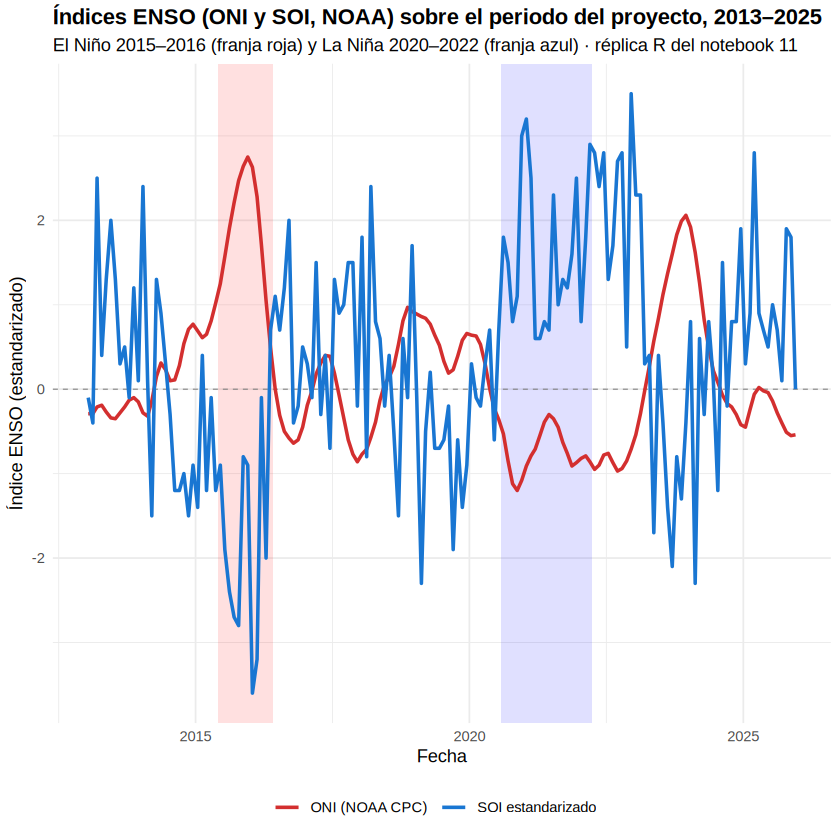

In [5]:
p_serie <- enso %>%
  pivot_longer(c(oni, soi), names_to = 'indice', values_to = 'valor') %>%
  mutate(indice = factor(indice, levels = c('oni','soi'),
                         labels = c('ONI (NOAA CPC)', 'SOI estandarizado'))) %>%
  ggplot(aes(date, valor, color = indice)) +
  annotate('rect', xmin = as.Date('2015-06-01'), xmax = as.Date('2016-05-31'),
           ymin = -Inf, ymax = Inf, alpha = 0.12, fill = 'red') +
  annotate('rect', xmin = as.Date('2020-08-01'), xmax = as.Date('2022-03-31'),
           ymin = -Inf, ymax = Inf, alpha = 0.12, fill = 'blue') +
  geom_hline(yintercept = 0, color = 'gray50', linewidth = 0.3, linetype = 'dashed') +
  geom_line(linewidth = 1) +
  scale_color_manual(values = c('ONI (NOAA CPC)' = '#D32F2F',
                                 'SOI estandarizado' = '#1976D2'), name = NULL) +
  labs(x = 'Fecha', y = 'Índice ENSO (estandarizado)',
       title = 'Índices ENSO (ONI y SOI, NOAA) sobre el periodo del proyecto, 2013–2025',
       subtitle = 'El Niño 2015–2016 (franja roja) y La Niña 2020–2022 (franja azul) · réplica R del notebook 11') +
  theme_minimal(base_size = 11) +
  theme(legend.position = 'bottom',
        plot.title = element_text(face = 'bold'))

ggsave(file.path(OUT_FIG, 'enso_serie_2013_2025_R.png'),
       p_serie, width = 12, height = 5, dpi = 200, bg = 'white')
print(p_serie)
cat('Guardado: enso_serie_2013_2025_R.png\n')

## 5. Correlación ONI/SOI vs NDVI z-score por naturaleza espectral y rezago

In [6]:
manglar     <- c('Cano_Palos', 'Cano_Clarin', 'CP_Aguas_Negras', 'CP_Luna')
limnologica <- c('Isla_Boqueron', 'Punta_Cerro', 'Punta_Chino', 'Rio_Sevilla')

ndvi <- read_csv(NDVI_CSV, show_col_types = FALSE) %>%
  mutate(naturaleza = case_when(
    subzona %in% manglar     ~ 'manglar',
    subzona %in% limnologica ~ 'limnologica',
    TRUE                     ~ 'otra'
  )) %>%
  filter(naturaleza %in% c('manglar','limnologica')) %>%
  group_by(subzona) %>%
  mutate(z = (ndvi - mean(ndvi, na.rm = TRUE)) / sd(ndvi, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(date = floor_date(as.Date(date), 'month') + days(14))

z_mensual <- ndvi %>%
  group_by(date, naturaleza) %>%
  summarise(z = mean(z, na.rm = TRUE), .groups = 'drop')

calcular_rho <- function(nat, lag_meses, var) {
  serie_n <- z_mensual %>% filter(naturaleza == nat) %>% select(date, z)
  serie_e <- enso %>% select(date, val = all_of(var))
  merged  <- inner_join(serie_n, serie_e, by = 'date') %>%
    arrange(date) %>%
    mutate(val_lag = lag(val, lag_meses)) %>%
    drop_na()
  list(rho = cor(merged$z, merged$val_lag), n = nrow(merged))
}

df_corr <- expand_grid(naturaleza = c('manglar','limnologica'),
                        rezago_meses = 0:3) %>%
  mutate(
    res_oni  = map2(naturaleza, rezago_meses, ~ calcular_rho(.x, .y, 'oni')),
    res_soi  = map2(naturaleza, rezago_meses, ~ calcular_rho(.x, .y, 'soi')),
    rho_oni  = round(map_dbl(res_oni, 'rho'), 3),
    rho_soi  = round(map_dbl(res_soi, 'rho'), 3),
    n        = map_int(res_oni, ~ as.integer(.x$n))
  ) %>%
  select(naturaleza, rezago_meses, rho_oni, rho_soi, n)

write_csv(df_corr, file.path(OUT_TAB, 'correlacion_enso_ndvi_R.csv'))
print(df_corr, n = 8)
cat('\nGuardado: correlacion_enso_ndvi_R.csv\n')

# A tibble: 8 × 5
  naturaleza  rezago_meses rho_oni rho_soi     n
  <chr>              <int>   <dbl>   <dbl> <int>
1 manglar                0   0.027   0.143    86
2 manglar                1  -0.007   0.198    85
3 manglar                2  -0.039   0.146    84
4 manglar                3  -0.07    0.058    83
5 limnologica            0  -0.121   0.201    72
6 limnologica            1  -0.089   0.12     71
7 limnologica            2  -0.054   0.135    70
8 limnologica            3  -0.014   0.153    69

Guardado: correlacion_enso_ndvi_R.csv


## 6. Figura comparativa de correlaciones por rezago (ggplot2)

Guardado: enso_vs_ndvi_correlacion_R.png


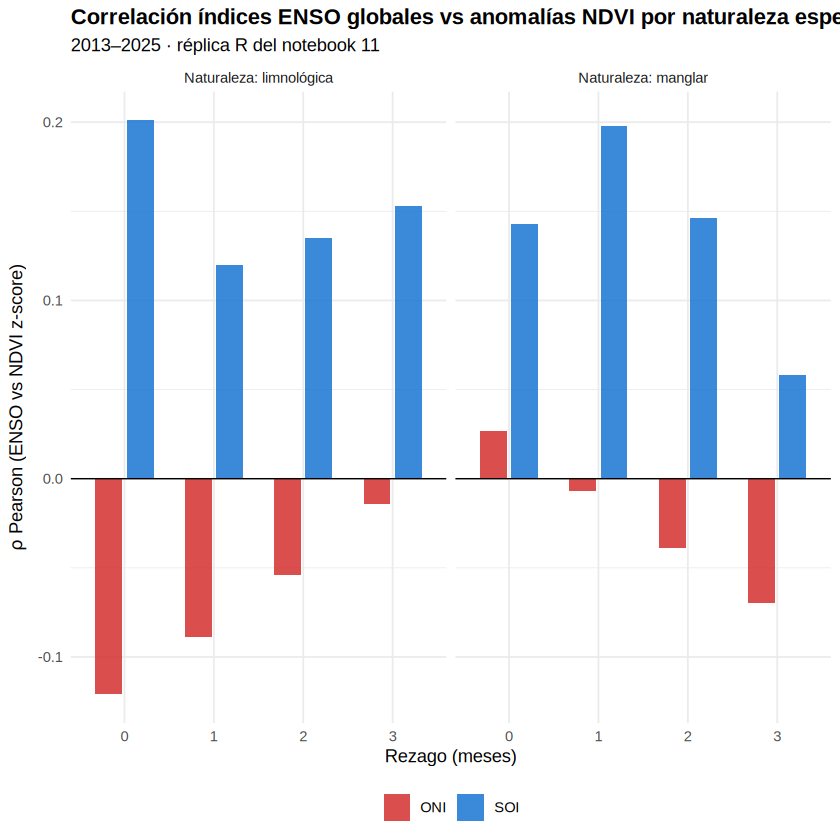

In [7]:
p_corr <- df_corr %>%
  pivot_longer(c(rho_oni, rho_soi), names_to = 'indice', values_to = 'rho') %>%
  mutate(indice = if_else(indice == 'rho_oni', 'ONI', 'SOI')) %>%
  ggplot(aes(x = factor(rezago_meses), y = rho, fill = indice)) +
  geom_col(position = position_dodge(0.7), width = 0.6, alpha = 0.85) +
  geom_hline(yintercept = 0, color = 'black', linewidth = 0.4) +
  facet_wrap(~ naturaleza, labeller = labeller(naturaleza = c(
    manglar = 'Naturaleza: manglar',
    limnologica = 'Naturaleza: limnológica'
  ))) +
  scale_fill_manual(values = c(ONI = '#D32F2F', SOI = '#1976D2'), name = NULL) +
  labs(x = 'Rezago (meses)',
       y = expression(rho * ' Pearson (ENSO vs NDVI z-score)'),
       title = 'Correlación índices ENSO globales vs anomalías NDVI por naturaleza espectral',
       subtitle = '2013–2025 · réplica R del notebook 11') +
  theme_minimal(base_size = 11) +
  theme(legend.position = 'bottom',
        plot.title = element_text(face = 'bold'))

ggsave(file.path(OUT_FIG, 'enso_vs_ndvi_correlacion_R.png'),
       p_corr, width = 12, height = 4.5, dpi = 200, bg = 'white')
print(p_corr)
cat('Guardado: enso_vs_ndvi_correlacion_R.png\n')

## 7. Verificación de convergencia con la versión Python

Si los valores de $\rho_{\text{ONI}}$ y $\rho_{\text{SOI}}$ calculados en R ---tabla `correlacion_enso_ndvi_R.csv`--- coinciden hasta tres decimales con los reportados en la tabla `correlacion_enso_ndvi.csv` del notebook 11 ---ver tabla @tbl-enso-corr del informe---, queda demostrado que el resultado del análisis ENSO no depende de la implementación ni del lenguaje, en este sentido la interpretación científica del informe ---el SOI emerge como mejor predictor del NDVI manglar con correlación positiva a rezagos de 1 a 2 meses, y la divergencia con la precipitación ERA5-Land local refleja la no-linealidad del acoplamiento climático sobre el manglar--- se sostiene con independencia del entorno computacional.